In [1]:
from utils.random_forest_utils.rf_preprocessing_utils import WindowAlgPreprocessor

rf_preprocessor = WindowAlgPreprocessor(sensors_path="../../../../data/ml/features.csv", target_path="../../../../data/ml/targets.csv")
sensors_df, target_df = rf_preprocessor.read_data()
sensors_df = rf_preprocessor.feature_selection()
rf_preprocessor.normalize_angle()
X = rf_preprocessor.group_and_pad(rf_preprocessor.sensor_df, group_col="Experiment_ID")
Y = rf_preprocessor.group_and_pad(rf_preprocessor.target_df, group_col="Experiment_ID")[:,:-1,1:-1]
X_rf, Y_rf = rf_preprocessor.prepare_rf_data(X, Y)

In [2]:
sensors_df[sensors_df["Experiment_ID"]==2]["MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]"]

Time_[s]
0.00     0.293651
0.05     0.285714
0.10     0.293651
0.15     0.293651
0.20     0.285714
           ...   
40.05    0.992064
40.10    0.992064
40.15    0.992064
40.20    0.992064
40.25    0.992064
Name: MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%], Length: 806, dtype: float64

In [3]:
from utils.random_forest_utils.model import RandomForestTrainer
trainer = RandomForestTrainer()

In [4]:
# trainer.train(X_rf, Y_rf)
# trainer.save_model("../../../../models/rf/rf_movement_machine.joblib")

In [5]:
rf = trainer.load_model("../../../../models/rf/rf_movement_machine.joblib")

Model loaded from ../../../../models/rf/rf_movement_machine.joblib


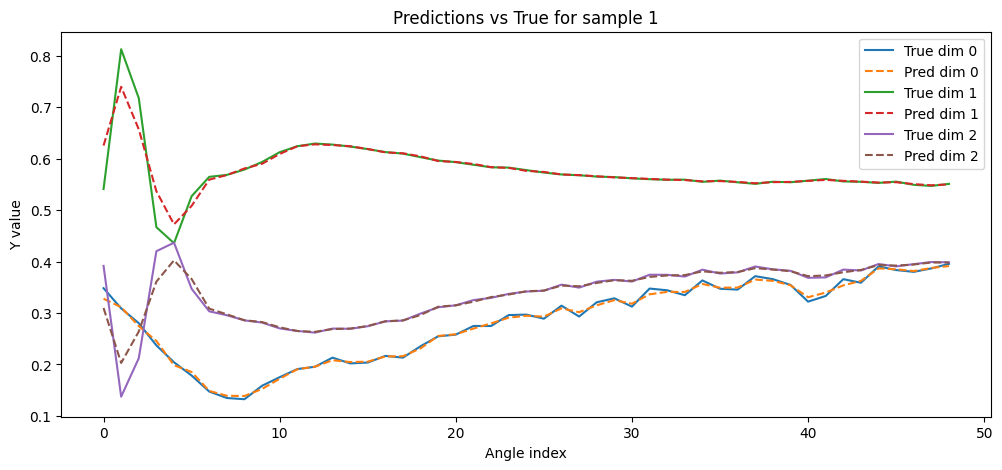

In [6]:
trainer.predict_by_experiment_angle(sample_idx=1, X=X, Y=Y)

In [8]:
from utils.random_forest_utils.window_importance_utils import WindowImportance

wi = WindowImportance(X, Y, rf, X.shape[2])
wi.interactive_window_plot(sensors_df, target_df)

interactive(children=(SelectionSlider(description='Experiment ID', options=(2, 4, 6, 8, 10, 12, 14, 16, 18, 20…